# Continuation of an equilibrium solution

2025-11-04. Continue an ODE equilibrium solution using BifurcationKit, compare to DNS

## 0. Preliminaries

In [218]:
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise
import JLD2 as jld
import BifurcationKit as BK

using CloudAtlas

#display("text/html", "<style>.container { width:100% !important; }</style>")

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

## 1. Construct ODE model, find equilibrium solution.

This repeats some code from notebook `find-ode-eqb.ipynb`.

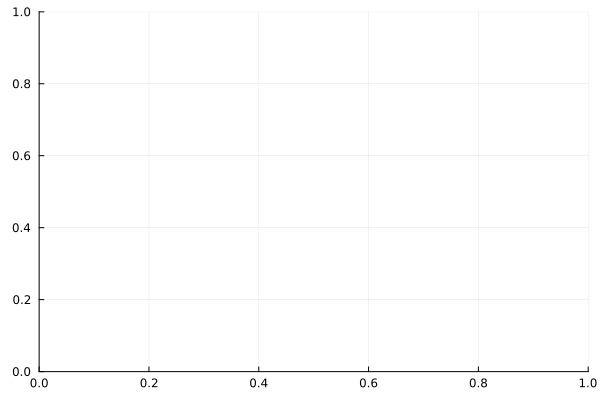

In [259]:
plot()

In [269]:
α, γ = 2pi/jld.load_object("simulated_data/x1-1-2-3-data.asc")[7,1][1], 2pi/jld.load_object("simulated_data/x1-1-2-3-data.asc")[7,1][2]                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
#α, γ = 2pi/LxLzErrors[1][1], 2pi/LxLzErrors[1][2]
#α, γ = 2pi/dataMatrix[4,5][1], 2pi/dataMatrix[4,5][2]
J,K,L = 1,2,3  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]             # Generators of the symmetric subspace of the Nagata eqb
#eq1 [sx*sy*sz, sz*tx*tz], eq7 [sx*sy, sz, tx*tz]

model = ODEModel(α, γ, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
m = length(model) = 27


Load initial guesses for EQ1 (lower branch) and EQ2 (upper branch) from
files. These are computed by projecting DNS solutions onto the basis, using channelflow. 

In [270]:
#xguess = myreaddlm("data/tech412-fluids/xeq7-Re200-2-3-5.asc") #data/xeq1projection-Re200-1-2-3-27d.asc
#xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc")
#xguess = LxLzErrors[1][4]
#xguess = dataMatrix[4,5][3]
xguess = jld.load_object("simulated_data/x1-1-2-3-data.asc")[7,1][4]

R = 200
#x = zeros(m)
@show norm(model.f(xguess, R)); #x, R

norm(model.f(xguess, R)) = 0.0014649743581186107


12-element Vector{Float64}:
  0.014698291916209177
 -0.0014897971010958877
  0.03543689418072967
 -0.011339395710230453
 -0.006312911221148409
  0.01686912270948017
  0.01408013682693845
  0.0006301610584667507
  0.003695458089376188
 -0.03332124437734743
 -0.010492496058385882
  0.005658443524327096

Find the ODE representations of the lower and upper branch solutions.

In [271]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  0.127381 seconds (81.31 k allocations: 4.298 MiB, 98.69% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 3.700936424264008e-9


## 2. Continuation of eqbs with BifurcationKit



Compute bifurcation diagram from xeq1 solution.

In [272]:
shear(xeq1, model)

2.0047258134633203

In [273]:
myshear = x -> shear(x,model)
myshear(xeq1)

2.0047258134633203

(J, K, L, m, R) = (1, 2, 3, 27, 200)


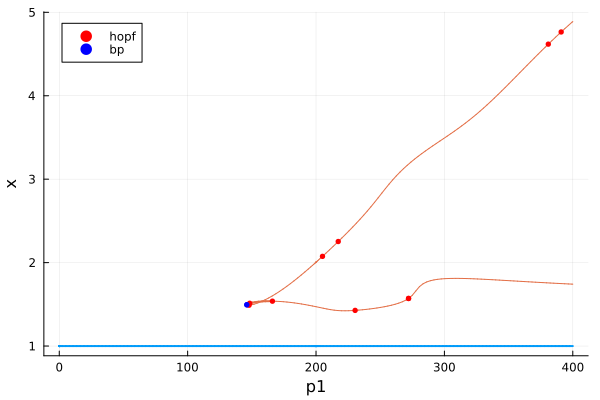

In [274]:
@show J, K, L, m, R

fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=2.0, #Ask Gibson why dsmin was set to 1e-07
    max_steps = 600, newton_options = newtopts)

br1 = false
#try
    br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)  #Ask Gibson what this does besides throw errors
    plot!(br1)
#catch e
#    println(e)
#end


Compute bifurcation diagram from xeq2 solution. For some reason BifurcationKit doesn't go around the saddle-node bifurcation. I need to learn how to tune the algorithm.

Plot the ODE bifurcation diagram along with the DNS.

In [ ]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
#@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, $J-$K-$L, $(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))

In [2]:
using Suppressor
minDNS = false
parameters = []
minimums = []
guesses = []
LxLzErrors = []
matrix = []

Any[]

In [168]:
function DataTable(Lx, Lz, center, posiN, negN, posiDeltaLz, negDeltaLz, J, K, L, H, Re, xGuess, normalize)
    @suppress begin
        try
            model = ODEModel(2pi/Lx, 2pi/Lz, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
            fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)

            ###@show norm(fr(xeq1))/norm(xeq1);
            ##################
            shear(xeq1, model)
            ##################
            myshear = x -> shear(x,model)
            myshear(xeq1)

            fp(x,p) = model.f(x,p[1])
            prob1 = BK.BifurcationProblem(fp,
                xeq1,         # initial condition x0
                [Float64(Re)], # set of parameters
                1;            # parameter index for continuation
                #record_from_solution = (x,p; k...) -> shear(x),
                plot_solution = (x,p; k...) -> myshear(x),
                record_from_solution = (x,p; k...) -> myshear(x),
            )

            newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
            contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=2.0, 
                max_steps = 600, newton_options = newtopts)

            br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

            ###plot!(br1, legendfontsize=fs)
            ##################
            ReD1 = [br1.param br1.x];
            ##################
            mask = ReD1[:, 2] .> 1.1
            if sum(mask) != 0
                truncReD1 = ReD1[mask, :]
            else
                truncReD1 = ReD1
            end
            #plot!(truncReD1[:,1], truncReD1[:,2], color=:green, label="", legendfontsize=5)
            #plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))
            if minimum(truncReD1[:,1]) > 1.1
                global matrix[center[2], center[1]] = minimum(truncReD1[:,1])
                global dataMatrix[center[2], center[1]] = [Lx, Lz, Re, xGuess, H, false]
                if posiN != 0
                    DataTable_Helper(Lx, Lz, [center[1], center[2] + 1], posiN, posiDeltaLz, J, K, L, H, Re, xeq1, normalize)
                end
                if negN != 0
                    DataTable_Helper(Lx, Lz, [center[1], center[2] - 1], negN, -negDeltaLz, J, K, L, H, Re, xeq1, normalize)
                end
                return xeq1;
            else
                global matrix[center[2], center[1]] = 60
                global dataMatrix[center[2], center[1]] = [Lx, Lz, Re, xGuess, H, true]
                if posiN != 0
                    DataTable_Helper(Lx, Lz, [center[1], center[2] + 1], posiN, posiDeltaLz, J, K, L, H, Re, xeq1, normalize)
                end
                if negN != 0
                    DataTable_Helper(Lx, Lz, [center[1], center[2] - 1], negN, -negDeltaLz, J, K, L, H, Re, xeq1, normalize)
                end
                push!(LxLzErrors, [Lx, Lz, Re, xGuess, "min is below p_min"])
                return xeq1;
            end
            #return [br1, ReD1, c, n, J, K, L, m, α, γ]
            #return [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])]
            #push!(vectorTable, [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])])
            #return vectorTable
        catch e
            #display(e)
            global matrix[center[2], center[1]] = 60
            global dataMatrix[center[2], center[1]] = [Lx, Lz, Re, xGuess, H, true]
            if posiN != 0
                DataTable_Helper(Lx, Lz, [center[1], center[2] + 1], posiN, posiDeltaLz, J, K, L, H, Re, xGuess, normalize)
            end
            if negN != 0
                DataTable_Helper(Lx, Lz, [center[1], center[2] - 1], negN, -negDeltaLz, J, K, L, H, Re, xGuess, normalize)
            end
            push!(LxLzErrors, [Lx, Lz, Re, xGuess, e])
            return xGuess;
        end
    end
end

DataTable (generic function with 1 method)

In [169]:
function DataTable_Helper(Lx, Lz, center, n, deltaLz, J, K, L, H, Re, xGuess, normalize)
    @suppress begin
        if n == 0
            return
        else
            Lz += deltaLz

            #display(α)
            #display(γ)
            try
                model = ODEModel(2pi/Lx, 2pi/Lz, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
                fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
                Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

                @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
                ##################
                shear(xeq1, model)
                ##################
                myshear = x -> shear(x,model)
                myshear(xeq1)
                ####I = myshear(xeq1)
                ##################
                ###@show J, K, L, m, R

                fp(x,p) = model.f(x,p[1])
                prob1 = BK.BifurcationProblem(fp,
                    xeq1,         # initial condition x0
                    [Float64(Re)], # set of parameters
                    1;            # parameter index for continuation
                    #record_from_solution = (x,p; k...) -> shear(x),
                    plot_solution = (x,p; k...) -> myshear(x),
                    record_from_solution = (x,p; k...) -> myshear(x),
                )

                newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
                contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=2.0, 
                    max_steps = 600, newton_options = newtopts)

                br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

                ###plot!(br1, legendfontsize=fs)
                ##################
                ReD1 = [br1.param br1.x];
                ##################
                mask = ReD1[:, 2] .> 1.1
                if sum(mask) != 0
                    truncReD1 = ReD1[mask, :]
                else
                    truncReD1 = ReD1
                end
                #plot!(truncReD1[:,1], truncReD1[:,2], color=:green, label="", legendfontsize=5)
                #plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))
                if minimum(truncReD1[:,1]) > 1.1
                    global matrix[center[2], center[1]] = minimum(truncReD1[:,1])
                    global dataMatrix[center[2], center[1]] = [Lx, Lz, Re, xGuess, H, false]
                    if signbit(deltaLz)
                        DataTable_Helper(Lx, Lz, [center[1], center[2] - 1], n - 1, deltaLz, J, K, L, H, Re, xeq1, normalize)
                    else
                        DataTable_Helper(Lx, Lz, [center[1], center[2] + 1], n - 1, deltaLz, J, K, L, H, Re, xeq1, normalize)
                    end
                else
                    global matrix[center[2], center[1]] = 60
                    global dataMatrix[center[2], center[1]] = [Lx, Lz, Re, xGuess, H, true]
                    if signbit(deltaLz)
                        DataTable_Helper(Lx, Lz, [center[1], center[2] - 1], n - 1, deltaLz, J, K, L, H, Re, xeq1, normalize)
                    else
                        DataTable_Helper(Lx, Lz, [center[1], center[2] + 1], n - 1, deltaLz, J, K, L, H, Re, xeq1, normalize)
                    end
                    push!(LxLzErrors, [Lx, Lz, Re, xGuess, "min is below p_min"])
                end
                #return [br1, ReD1, c, n, J, K, L, m, α, γ]
                #return [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])]
                #push!(vectorTable, [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])])
                #return vectorTable
            catch e
                #display(e)
                global matrix[center[2], center[1]] = 60
                global dataMatrix[center[2], center[1]] = [Lx, Lz, Re, xGuess, H, true]
                if signbit(deltaLz)
                    DataTable_Helper(Lx, Lz, [center[1], center[2] - 1], n - 1, deltaLz, J, K, L, H, Re, xGuess, normalize)
                else
                    DataTable_Helper(Lx, Lz, [center[1], center[2] + 1], n - 1, deltaLz, J, K, L, H, Re, xGuess, normalize)
                end
                push!(LxLzErrors, [Lx, Lz, Re, xGuess, e])
            end
        end
    end
end

DataTable_Helper (generic function with 1 method)

In [ ]:
function xGuessFinder(Lx, Lz, LxLzRatio, n, posRan, negRan, J, K, L, H, Re, xGuess, normalize)
    @suppress begin
        minParam = [Lx, Lz]
        model = ODEModel(2pi/Lx, 2pi/Lz, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
        ##################
        fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
        ##################
        shearVal = shear(xeq1, model)

        if(abs(shearVal - 1) < 0.01)
            model = ODEModel(2pi/Lx, 2pi/Lz, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
            ##################
            fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
            ##################
            shear(xeq1, model)
        end


        ##################
        myshear = x -> shear(x,model)
        myshear(xeq1)

        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(Re)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
        )

        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
        contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=2.0, 
            max_steps = 600, newton_options = newtopts)

        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
        ReD1 = [br1.param br1.x];
        minRe = minimum(ReD1[:,1])
        xGuess = xeq1
        
        numOfTests = n
        posiRangeOfChange = posRan #1.5
        negRangeOfChange = negRan #0.85 #Do not set to 0
        delta = (posiRangeOfChange + negRangeOfChange)/numOfTests
        numOfNegTests = round(negRangeOfChange/delta)
        if numOfNegTests != 0
            negDelta = negRangeOfChange / numOfNegTests
        else 
            negDelta = 0
        end
        negMin, negParam, negXGuess = xGuessFinder_Helper(Lx, Lz, LxLzRatio, n, -negDelta, J, K, L, H, Re, xGuess, minRe, minParam, xGuess, normalize)
        #push!(matrix, vcat([Re, initialA, initialY, true], xguess))

        numOfPosiTests = numOfTests - numOfNegTests
        if numOfPosiTests != 0
            posiDelta = posiRangeOfChange / numOfPosiTests
        else 
            posiDelta = 0
        end
        posiMin, posiParam, posiXGuess = xGuessFinder_Helper(Lx, Lz, LxLzRatio, n, posiDelta, J, K, L, H, Re, xGuess, minRe, minParam, xGuess, normalize)
        
        #display(negMin)
        #display(posiMin)
        #display(minRe)
        if posiMin < negMin && posiMin < minRe
            return posiParam, posiXGuess
        elseif negMin < posiMin && negMin < minRe
            return negParam, negXGuess
        else 
            return minParam, xGuess
        end
    end
end

xGuessFinder (generic function with 1 method)

In [6]:
function xGuessFinder_Helper(Lx, Lz, LxLzRatio, n, deltaLx, J, K, L, H, Re, xGuess, minRe, minParam, minXGuess, normalize)
    @suppress begin
        if n == 0
            return minRe, minParam, minXGuess
        else
            Lx += deltaLx
            Lz += deltaLx * LxLzRatio
            try
                model = ODEModel(2pi/Lx, 2pi/Lz, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
                ##################
                fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
                Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

                @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
                ##################
                shear(xeq1, model)
                ##################
                myshear = x -> shear(x,model)
                myshear(xeq1)
                #display(xeq1)

                fp(x,p) = model.f(x,p[1])
                prob1 = BK.BifurcationProblem(fp,
                    xeq1,         # initial condition x0
                    [Float64(Re)], # set of parameters
                    1;            # parameter index for continuation
                    #record_from_solution = (x,p; k...) -> shear(x),
                    plot_solution = (x,p; k...) -> myshear(x),
                    record_from_solution = (x,p; k...) -> myshear(x),
                )

                newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
                contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=2.0, 
                    max_steps = 600, newton_options = newtopts)

                br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
                ##################
                ReD1 = [br1.param br1.x];
                ##################
                mask = ReD1[:, 2] .> 1.1
                if sum(mask) != 0
                    truncReD1 = ReD1[mask, :]
                else
                    truncReD1 = ReD1
                end
                if minimum(truncReD1[:,1]) > 1.1
                    if minimum(truncReD1[:,1]) < minRe
                        return xGuessFinder_Helper(Lx, Lz, LxLzRatio, n - 1, deltaLx, J, K, L, H, Re, xeq1, minimum(truncReD1[:,1]), [Lx,Lz], xeq1, normalize)
                    else
                        return xGuessFinder_Helper(Lx, Lz, LxLzRatio, n - 1, deltaLx, J, K, L, H, Re, xeq1, minRe, minParam, minXGuess, normalize)
                    end
                else
                    return xGuessFinder_Helper(Lx, Lz, LxLzRatio, n - 1, deltaLx, J, K, L, H, Re, xeq1, minRe, minParam, minXGuess, normalize)
                end
            catch e
                #display(Text(sprint(io -> Base.showerror(io, e, catch_backtrace()))))
                return xGuessFinder_Helper(Lx, Lz, LxLzRatio, n - 1, deltaLx, J, K, L, H, Re, xGuess, minRe, minParam, minXGuess, normalize)
            end
        end
    end
end

xGuessFinder_Helper (generic function with 1 method)

In [7]:
function LxLzValues(Lx, Lz, posiLxTests, posiLxDelta, negLxTests, negLxDelta, posiLzTests, posiLzDelta, negLzTests, negLzDelta)
    push!(LxValues, Lx)
    push!(LzValues, Lz)

    for i in 1:negLxTests
        pushfirst!(LxValues, Lx - i * negLxDelta)
    end

    for i in 1:posiLxTests
        push!(LxValues, Lx + i * posiLxDelta)
    end

    for i in 1:negLzTests
        pushfirst!(LzValues, Lz - i * negLzDelta)
    end

    for i in 1:posiLzTests
        push!(LzValues, Lz + i * posiLzDelta)
    end
end

LxLzValues (generic function with 1 method)

In [8]:
function contourMaker(Lx, LxRange, Lz, LzRange, J, K, L, H, Re, xGuess, numOfTestsLx, normalize)
    @suppress begin

        LxLzRatio = (LzRange[2] - LzRange[1])/(LxRange[2] - LxRange[1])
        numOfTestsLz = round(Int, numOfTestsLx * LxLzRatio)

        minParam, minXGuess = xGuessFinder(Lx, Lz, LxLzRatio, numOfTestsLx, 
                                        min(LxRange[2] - Lx, (LzRange[2] - Lz)/LxLzRatio), 
                                        min(Lx - LxRange[1], (Lz - LzRange[1])/LxLzRatio), 
                                        J, K, L, H, Re, xGuess, normalize)
        Lx, Lz = minParam
        #display(minParam)
        #display(minXGuess)

        global matrix = zeros(numOfTestsLz + 1, numOfTestsLx + 1)
        global dataMatrix = Matrix{Any}(undef, numOfTestsLz + 1, numOfTestsLx + 1)
        minDNS = 163.5222

        negRangeOfChangeInLx = (Lx - LxRange[1])
        posiRangeOfChangeInLx = (LxRange[2] - Lx)
        
        deltaLx = (negRangeOfChangeInLx + posiRangeOfChangeInLx) / numOfTestsLx
        negLxTests = round(negRangeOfChangeInLx / deltaLx)
        if negLxTests != 0
            negLxDelta = negRangeOfChangeInLx / negLxTests
        else 
            negLxDelta = 0
        end

        negRangeOfChangeInLz = (Lz - LzRange[1])
        posiRangeOfChangeInLz = (LzRange[2] - Lz)

        deltaLz = (negRangeOfChangeInLz + posiRangeOfChangeInLz) / numOfTestsLz
        negLzTests = round(negRangeOfChangeInLz / deltaLz)
        if negLzTests != 0
            negLzDelta = negRangeOfChangeInLz / negLzTests
        else 
            negLzDelta = 0
        end


        posiLxTests = numOfTestsLx - negLxTests
        if posiLxTests != 0
            posiLxDelta = posiRangeOfChangeInLx / posiLxTests
        else 
            posiLxDelta = 0
        end

        posiLzTests = numOfTestsLz - negLzTests
        if posiLzTests != 0
            posiLzDelta = posiRangeOfChangeInLz / posiLzTests
        else 
            posiLzDelta = 0
        end
        
        #=
        display(Lx)
        display(Lz)
        display(numOfTestsLx)
        display(numOfTestsLz)
        display("negRangeOfChangeInLx : $negRangeOfChangeInLx, deltaLx : $deltaLx, negLxTests : $negLxTests, negLxDelta : $negLxDelta")
        display("negRangeOfChangeInLz : $negRangeOfChangeInLz, deltaLz : $deltaLz, negLzTests : $negLzTests, negLzDelta : $negLzDelta")
        display("posiRangeOfChangeInLx : $posiRangeOfChangeInLx, deltaLx : $deltaLx, posiLxTests : $posiLxTests, posiLxDelta : $posiLxDelta")
        display("posiRangeOfChangeInLz : $posiRangeOfChangeInLz, deltaLz : $deltaLz, posiLzTests : $posiLzTests, posiLzDelta : $posiLzDelta")
        =#
        

        xGuess = minXGuess
        for i in 0:negLxTests
            #DataTable(α, γ, center, posiN, negN, posiDeltaγ, negDeltaγ, J, K, L, H, Re, xGuess)
            #plot()
            xGuess = DataTable(Lx - i * negLxDelta, Lz, 
                     [round(Int, negLxTests + 1 - i), round(Int, negLzTests + 1)],
                     posiLzTests, negLzTests, posiLzDelta, negLzDelta, J, K, L, H, Re, xGuess, normalize)
            #display(plot!(xlabel="Re", ylabel="I", xlim=(75,300), ylim=(1,3.5)))
        end

        xGuess = minXGuess
        for i in 1:posiLxTests
            #plot()
            xGuess = DataTable(Lx + i * posiLxDelta, Lz, 
                     [round(Int, negLxTests + 1 + i), round(Int, negLzTests + 1)], 
                     posiLzTests, negLzTests, posiLzDelta, negLzDelta, J, K, L, H, Re, xGuess, normalize)
            #display(plot!(xlabel="Re", ylabel="I", xlim=(75,300), ylim=(1,3.5)))
        end

        LxLzValues(Lx, Lz, posiLxTests, posiLxDelta, negLxTests, negLxDelta, posiLzTests, posiLzDelta, negLzTests, negLzDelta)

        #display(matrix)
        #display(contour(LxValues, LzValues, matrix, xlabel="Lx", ylabel="Lz", lw=0, levels=200, fill = true, colormap =:jet))
        #display(contour(reverse((2*pi)./LxValues), reverse((2*pi)./LzValues), rot180(matrix), xlabel="α", ylabel="γ", lw=0, levels=200, fill = true, colormap =:jet))
        #display(contour(αRange[1]:(αRange[2] - αRange[1])/numOfTestsα:αRange[2], γRange[1]:(γRange[2] - γRange[1])/numOfTestsγ:γRange[2], matrix, xlabel="α", ylabel="γ", lw=0, levels=200, fill = true, colormap =:jet))
        #display(contour(reverse(collect(range((2*pi/αRange[1]), stop=(2*pi/(αRange[2])), length=size(matrix, 2)))), reverse(collect(range((2*pi/γRange[1]), stop=(2*pi/γRange[2]), length=size(matrix, 1)))), rot180(matrix), xlabel="Lx", ylabel="Lz", lw=0, levels=200, fill = true, colormap =:jet))
    end
end

contourMaker (generic function with 1 method)

In [ ]:
Lx, Lz= 2pi, pi                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
LxRange = [2pi, 4pi] 
LzRange = [pi, 2pi]
numOfTestsLx = 35
J,K,L = 2,4,7  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy, sz, tx*tz]  #eq1 [sx*sy*sz, sz*tx*tz], eq7 [sx*sy, sz, tx*tz]
Re = 200
normalize = false #Unused currently
matrix = []
dataMatrix = []
LxLzErrors = []
LxValues = []
LzValues = []
xguess = myreaddlm("data/tech412-fluids/xeq7-Re200-$J-$K-$L.asc") #data/xeq1projection-Re200-1-2-3-27d.asc
#xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc")
contourMaker(Lx, LxRange, Lz, LzRange, J, K, L, H, Re, xguess, numOfTestsLx, normalize)

In [ ]:
display(matrix)
display(dataMatrix)
display(LxValues)
display(LzValues)
#display(dataMatrix[1,5][4])
#display(reverse((2*pi)./LxValues))
#display(reverse((2*pi)./LzValues))

In [ ]:
jld.load_object("simulated_data/x7-1-2-3-data.asc")[7,1]

In [279]:
#=open("simulated_data/x7-$J-$K-$L-minRe.asc", "w") do io
    writedlm(io, matrix)
end
open("simulated_data/x7-$J-$K-$L-data.asc", "w") do io
    writedlm(io, dataMatrix)
end=#
jld.jldsave("simulated_data/x7-$J-$K-$L-minRe.asc"; matrix)
jld.jldsave("simulated_data/x7-$J-$K-$L-data.asc"; dataMatrix)
#save_object("simulated_data/test.asc", [1,2,3])
#load_object("simulated_data/x7-$J-$K-$L-minRe.asc")

In [ ]:
display(heatmap(LxValues, LzValues, matrix, xlabel="Lx", ylabel="Lz", colormap =:jet))#, clim=(80,100)))
#savefig("trash12.png")
display(contour(LxValues, LzValues, matrix, xlabel="Lx", ylabel="Lz", lw=0, levels=200, fill = true, colormap =:jet))
#savefig("trash13.png")
display(contour(reverse((2*pi)./LxValues), reverse((2*pi)./LzValues), rot180(matrix), xlabel="α", ylabel="γ", lw=0, levels=200, fill = true, colormap =:jet))
#savefig("trash14.png")
###matrix = myreaddlm("filename.asc")
#display(contour(αRange[1]:(αRange[2] - αRange[1])/numOfTestsα:αRange[2], γRange[1]:(γRange[2] - γRange[1])/round(numOfTestsα * γ / α):γRange[2], matrix, xlabel="α", ylabel="γ", lw=0, levels=200, fill = true, colormap =:jet))
#display(contour(reverse(collect(range((2*pi/αRange[1]), stop=(2*pi/(αRange[2])), length=size(matrix, 2)))), reverse(collect(range((2*pi/γRange[1]), stop=(2*pi/γRange[2]), length=size(matrix, 1)))), rot180(matrix), xlabel="Lx", ylabel="Lz", lw=0, levels=200, fill = true, colormap =:jet))

In [ ]:
#display(getindex.(LxLzErrors, 5))
#display(dataMatrix[1,5][3])
display(LxLzErrors)
#println(LxLzErrors[1])
#display(LxLzErrors)